<a href="https://colab.research.google.com/github/contactdilarayilmaz/asteroid-classification/blob/main/Colab%20Notebooks/04_neural_network_challenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NASA Asteroid Sınıflandırma Projesi
## Notebook 04 — Neural Network + SMOTE + Feature Engineering

**Bu notebook'ta yapacaklarımız:**

| Adım | Konu | Amaç |
|------|------|-------|
| 1 | Kurulum & Veri | Drive'dan yükle, hazırla |
| 2 | Feature Engineering | Fiziksel anlamlı yeni özellikler üret |
| 3 | SMOTE Analizi | Sınıf dengesizliğini çöz ve görselleştir |
| 4 | NN Mimarisi | Model tasarımı ve kararların gerekçeleri |
| 5 | Eğitim Fonksiyonu | Tekrar kullanılabilir pipeline |
| 6 | 4 Konfigürasyon | Baseline / +SMOTE / +FE / +SMOTE+FE |
| 7 | Klasik Modeller | RF & XGBoost karşılaştırma için |
| 8 | Sonuç Tablosu | Tüm modeller tek tabloda |
| 9 | Training Curves | Loss / F1 / Recall eğrileri |
| 10 | Confusion Matrix | 6 model yan yana |
| 11 | ROC & PR Eğrileri | Eşik bağımsız performans |
| 12 | Radar Chart | Çok metrikli görsel karşılaştırma |
| 13 | Katkı Analizi | Her bileşenin izole etkisi |

> **Deney mantığı:** Her adımda sadece **bir değişken** ekliyoruz.
> Bu sayede SMOTE'un ve Feature Engineering'in katkısını birbirinden bağımsız ölçebiliyoruz.

---
*Önceki adım:* `03_spice_visualization.ipynb`


## 1. Kurulum & Import

In [3]:
!pip install torch torchvision imbalanced-learn shap xgboost -q
print('✅ Kütüphaneler hazır!')


✅ Kütüphaneler hazır!


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score,
    confusion_matrix, roc_curve, precision_recall_curve
)
import xgboost as xgb
from imblearn.over_sampling import SMOTE

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

plt.style.use('dark_background')
sns.set_palette('husl')
pd.set_option('display.float_format', '{:.4f}'.format)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Import tamamlandı')
print(f'🖥️  Cihaz: {device}  |  PyTorch: {torch.__version__}')


✅ Import tamamlandı
🖥️  Cihaz: cpu  |  PyTorch: 2.10.0+cpu


## 2. Veriyi Yükle

In [5]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_PATH = '/content/drive/MyDrive/nasa_asteroid/'

print('Veriler Drive\'dan yükleniyor...')

# 1. Ham veriler
X_train_raw = pd.read_csv(DRIVE_PATH + 'X_train_raw.csv')
X_test_raw  = pd.read_csv(DRIVE_PATH + 'X_test.csv')

# 2. Feature engineering verileri
X_train_fe  = pd.read_csv(DRIVE_PATH + 'X_train_fe_scaled.csv')
X_test_fe   = pd.read_csv(DRIVE_PATH + 'X_test_fe_scaled.csv')

# 3. Hedef Değişken (y)
y_train     = pd.read_csv(DRIVE_PATH + 'y_train.csv').squeeze()
y_test      = pd.read_csv(DRIVE_PATH + 'y_test.csv').squeeze()

print('✅ Tüm veriler başarıyla yüklendi!\n')

# --- KONTROL ÇIKTILARI ---
print(f'PHA Oranı — Train: %{y_train.mean()*100:.1f} | Test: %{y_test.mean()*100:.1f}\n')

print('1. HAM VERİ (FE YOK)')
print(f'   Train: {X_train_raw.shape[0]:,} × {X_train_raw.shape[1]} | Test: {X_test_raw.shape[0]:,} × {X_test_raw.shape[1]}')
print(f'   Özellikler: {list(X_train_raw.columns)}\n')

print('2. FEATURE ENGINEERING (FE VAR + SCALED)')
print(f'   Train: {X_train_fe.shape[0]:,} × {X_train_fe.shape[1]} | Test: {X_test_fe.shape[0]:,} × {X_test_fe.shape[1]}')
print(f'   Özellikler: {list(X_train_fe.columns)}')


Mounted at /content/drive
Veriler Drive'dan yükleniyor...
✅ Tüm veriler başarıyla yüklendi!

PHA Oranı — Train: %9.7 | Test: %9.7

1. HAM VERİ (FE YOK)
   Train: 72,668 × 4 | Test: 18,168 × 4
   Özellikler: ['est_diameter_min', 'relative_velocity', 'miss_distance', 'absolute_magnitude']

2. FEATURE ENGINEERING (FE VAR + SCALED)
   Train: 72,668 × 11 | Test: 18,168 × 11
   Özellikler: ['est_diameter_min', 'relative_velocity', 'miss_distance', 'absolute_magnitude', 'est_diameter_km', 'magnitude_squared', 'velocity_x_distance', 'size_velocity_ratio', 'log_miss_distance', 'log_relative_velocity', 'log_est_diameter_min']


## 3. SMOTE Analizi

Veri setindeki ~%9.7 PHA oranı modeli majority class'a yönlendirir.
SMOTE sentetik azınlık örnekleri üreterek bu dengesizliği giderir.


In [6]:
def preprocess(X_tr, X_te, y_tr, apply_smote=False):
    imp = SimpleImputer(strategy='median')
    X_tr_imp = pd.DataFrame(imp.fit_transform(X_tr), columns=X_tr.columns)
    X_te_imp  = pd.DataFrame(imp.transform(X_te),    columns=X_te.columns)

    sc = StandardScaler()
    X_tr_sc = pd.DataFrame(sc.fit_transform(X_tr_imp), columns=X_tr.columns)
    X_te_sc  = pd.DataFrame(sc.transform(X_te_imp),    columns=X_te.columns)

    if apply_smote:
        smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
        X_res, y_res = smote.fit_resample(X_tr_sc, y_tr)
        X_res = pd.DataFrame(X_res, columns=X_tr.columns)
        print(f'   SMOTE öncesi: {y_tr.sum():,} PHA / {len(y_tr):,} '
              f'(%{y_tr.mean()*100:.1f})')
        print(f'   SMOTE sonrası: {int(y_res.sum()):,} PHA / {len(y_res):,} '
              f'(%{y_res.mean()*100:.1f})')
        return X_res, X_te_sc, pd.Series(y_res)
    return X_tr_sc, X_te_sc, y_tr.reset_index(drop=True)

print('📦 Konfigürasyon 1 — Baseline')
X1_tr, X1_te, y1_tr = preprocess(X_train_raw, X_test_raw, y_train)
print('\n📦 Konfigürasyon 2 — + SMOTE')
X2_tr, X2_te, y2_tr = preprocess(X_train_raw, X_test_raw, y_train, apply_smote=True)
print('\n📦 Konfigürasyon 3 — + FE')
X3_tr, X3_te, y3_tr = preprocess(X_train_fe, X_test_fe, y_train)
print('\n📦 Konfigürasyon 4 — + SMOTE + FE')
X4_tr, X4_te, y4_tr = preprocess(X_train_fe, X_test_fe, y_train, apply_smote=True)
print('\n✅ 4 konfigürasyon hazır')


📦 Konfigürasyon 1 — Baseline

📦 Konfigürasyon 2 — + SMOTE
   SMOTE öncesi: 7,072 PHA / 72,668 (%9.7)
   SMOTE sonrası: 65,596 PHA / 131,192 (%50.0)

📦 Konfigürasyon 3 — + FE

📦 Konfigürasyon 4 — + SMOTE + FE
   SMOTE öncesi: 7,072 PHA / 72,668 (%9.7)
   SMOTE sonrası: 65,596 PHA / 131,192 (%50.0)

✅ 4 konfigürasyon hazır


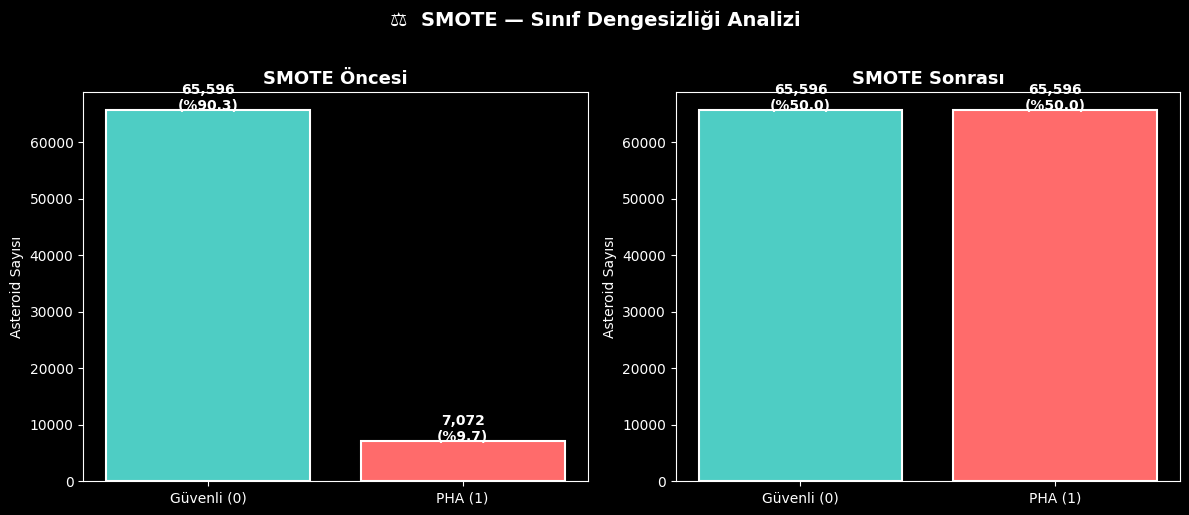

💾 smote_comparison.png kaydedildi


In [7]:
import matplotlib.pyplot as plt
import pandas as pd

# SMOTE görselleştirme
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (counts, title) in zip(axes, [
    (y_train.value_counts().sort_index(), 'SMOTE Öncesi'),
    (pd.Series(y2_tr).value_counts().sort_index(), 'SMOTE Sonrası'),
]):
    ax.bar(['Güvenli (0)', 'PHA (1)'], counts,
           color=['#4ECDC4', '#FF6B6B'], edgecolor='white', linewidth=1.5)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Asteroid Sayısı')
    total = counts.sum()
    for i, v in enumerate(counts):
        ax.text(i, v + 50, f'{v:,}\n(%{v/total*100:.1f})',
                ha='center', fontweight='bold')

plt.suptitle('⚖️  SMOTE — Sınıf Dengesizliği Analizi', fontsize=14,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('smote_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 smote_comparison.png kaydedildi')


## 5. Neural Network Mimarisi

Tabular veri için **Fully Connected Network** kullanıyoruz.

| Tasarım Kararı | Seçim | Gerekçe |
|---|---|---|
| Katman sayısı | 4 hidden layer | Tabular veri için yeterli kapasite |
| Aktivasyon | ReLU | Vanishing gradient yok, hızlı eğitim |
| Batch Normalization | Her katmandan sonra | Eğitimi stabilize eder, LR'yi duyarsızlaştırır |
| Dropout | 0.3 → 0.3 → 0.2 | Aşamalı azalan düzenleme |
| Output | Sigmoid | Binary sınıflandırma için 0–1 olasılık |
| Optimizer | Adam + weight_decay | Adaptif LR + L2 düzenleme |
| Scheduler | ReduceLROnPlateau | Val loss durduğunda LR'yi yarıya indir |
| Early Stopping | patience=12 | Overfit'i otomatik durdur |


In [8]:
class AsteroidNet(nn.Module):
    def __init__(self, input_size, dropout1=0.3, dropout2=0.2):
        super(AsteroidNet, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout1),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout1),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout2),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x).squeeze(1)

test_m = AsteroidNet(X1_tr.shape[1])
n_params = sum(p.numel() for p in test_m.parameters() if p.requires_grad)
print(f'✅ AsteroidNet')
print(test_m)
print(f'\nEğitilebilir parametre: {n_params:,}')


✅ AsteroidNet
AsteroidNet(
  (network): Sequential(
    (0): Linear(in_features=4, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=64, out_features=32, bias=True)
    (13): ReLU()
    (14): Linear(in_features=32, out_features=1, bias=True)
    (15): Sigmoid()
  )
)

Eğitilebilir parametre: 45,441


## 6. Eğitim Fonksiyonu

In [9]:
def train_nn(X_tr_df, y_tr_s, X_te_df, y_te_s,
             n_epochs=80, batch_size=512, lr=1e-3,
             patience=12, config_name='Model', use_pos_weight=True):

    X_tr = torch.FloatTensor(X_tr_df.values).to(device)
    y_tr = torch.FloatTensor(y_tr_s.values).to(device)
    X_te = torch.FloatTensor(X_te_df.values).to(device)
    y_te = torch.FloatTensor(y_te_s.values).to(device)

    train_dl = DataLoader(TensorDataset(X_tr, y_tr),
                          batch_size=batch_size, shuffle=True)

    model     = AsteroidNet(X_tr.shape[1]).to(device)
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5)

    # Sınıf dengesizliği için sample weight
    pos_w = float((y_tr_s == 0).sum() / max((y_tr_s == 1).sum(), 1))
    pw    = pos_w if use_pos_weight else 1.0

    history = {k: [] for k in ['train_loss','val_loss',
                                'train_acc','val_acc',
                                'val_f1','val_recall']}
    best_val_loss, best_state, no_improve = float('inf'), None, 0

    for epoch in range(n_epochs):
        # Train
        model.train()
        t_losses, t_correct, t_total = [], 0, 0
        for Xb, yb in train_dl:
            optimizer.zero_grad()
            out  = model(Xb)
            w    = torch.where(yb == 1,
                               torch.tensor(pw).to(device),
                               torch.tensor(1.0).to(device))
            loss = (criterion(out, yb) * w).mean()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            t_losses.append(loss.item())
            t_correct += ((out > 0.5) == yb).sum().item()
            t_total   += len(yb)

        # Val
        model.eval()
        with torch.no_grad():
            vp   = model(X_te)
            vw   = torch.where(y_te == 1,
                               torch.tensor(pw).to(device),
                               torch.tensor(1.0).to(device))
            vloss = (criterion(vp, y_te) * vw).mean().item()
            vpb   = (vp.cpu().numpy() > 0.5).astype(int)
            vtn   = y_te.cpu().numpy().astype(int)

        vf1  = f1_score(vtn, vpb, zero_division=0)
        vrec = recall_score(vtn, vpb, zero_division=0)
        vacc = accuracy_score(vtn, vpb)

        history['train_loss'].append(np.mean(t_losses))
        history['val_loss'].append(vloss)
        history['train_acc'].append(t_correct / t_total)
        history['val_acc'].append(vacc)
        history['val_f1'].append(vf1)
        history['val_recall'].append(vrec)
        scheduler.step(vloss)

        if vloss < best_val_loss - 1e-4:
            best_val_loss = vloss
            best_state    = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve    = 0
        else:
            no_improve += 1
        if no_improve >= patience:
            print(f'   Early stopping — epoch {epoch+1}')
            break
        if (epoch + 1) % 10 == 0:
            print(f'   [{epoch+1:3d}/{n_epochs}] loss={np.mean(t_losses):.4f} '
                  f'val_loss={vloss:.4f} F1={vf1:.4f} Recall={vrec:.4f}')

    if best_state:
        model.load_state_dict(best_state)

    model.eval()
    with torch.no_grad():
        fp  = model(X_te).cpu().numpy()
        fpb = (fp > 0.5).astype(int)

    yte_np = y_te_s.values
    metrics = {
        'Config'    : config_name,
        'Accuracy'  : accuracy_score(yte_np, fpb),
        'Precision' : precision_score(yte_np, fpb, zero_division=0),
        'Recall'    : recall_score(yte_np, fpb, zero_division=0),
        'F1'        : f1_score(yte_np, fpb, zero_division=0),
        'ROC-AUC'   : roc_auc_score(yte_np, fp),
        'PR-AUC'    : average_precision_score(yte_np, fp),
        'y_pred'    : fpb,
        'y_proba'   : fp,
        'model'     : model,
    }
    print(f'  ✅ {config_name} | Recall={metrics["Recall"]:.4f} '
          f'F1={metrics["F1"]:.4f} ROC-AUC={metrics["ROC-AUC"]:.4f}')
    return model, history, metrics


## 7. Dört Konfigürasyonu Eğit

In [10]:
all_histories, all_metrics = {}, {}

print('='*60)
print('📌 KONFİGÜRASYON 1 — Baseline (ham veri, SMOTE yok)')
print('='*60)
_, h1, m1 = train_nn(X1_tr, y1_tr, X1_te, y_test,
                      config_name='NN — Baseline', use_pos_weight=True)
all_histories['Baseline'], all_metrics['Baseline'] = h1, m1


📌 KONFİGÜRASYON 1 — Baseline (ham veri, SMOTE yok)
   [ 10/80] loss=0.3488 val_loss=1.6615 F1=0.0001 Recall=0.0006
   Early stopping — epoch 13
  ✅ NN — Baseline | Recall=0.0000 F1=0.0000 ROC-AUC=0.1342


In [11]:
print('='*60)
print('📌 KONFİGÜRASYON 2 — NN + SMOTE')
print('='*60)
_, h2, m2 = train_nn(X2_tr, y2_tr, X2_te, y_test,
                      config_name='NN + SMOTE', use_pos_weight=False)
all_histories['SMOTE'], all_metrics['SMOTE'] = h2, m2


📌 KONFİGÜRASYON 2 — NN + SMOTE
   [ 10/80] loss=0.3078 val_loss=2.3066 F1=0.1611 Recall=0.8699
   Early stopping — epoch 17
  ✅ NN + SMOTE | Recall=0.0000 F1=0.0000 ROC-AUC=0.1318


In [12]:
print('='*60)
print('📌 KONFİGÜRASYON 3 — NN + Feature Engineering')
print('='*60)
_, h3, m3 = train_nn(X3_tr, y3_tr, X3_te, y_test,
                      config_name='NN + FE', use_pos_weight=True)
all_histories['FE'], all_metrics['FE'] = h3, m3


📌 KONFİGÜRASYON 3 — NN + Feature Engineering
   [ 10/80] loss=0.3457 val_loss=69.3598 F1=0.1575 Recall=0.3693
   Early stopping — epoch 13
  ✅ NN + FE | Recall=0.0000 F1=0.0000 ROC-AUC=0.5000


In [13]:
print('='*60)
print('📌 KONFİGÜRASYON 4 — NN + SMOTE + FE')
print('='*60)
_, h4, m4 = train_nn(X4_tr, y4_tr, X4_te, y_test,
                      config_name='NN + SMOTE + FE', use_pos_weight=False)
all_histories['SMOTE+FE'], all_metrics['SMOTE+FE'] = h4, m4


📌 KONFİGÜRASYON 4 — NN + SMOTE + FE
   [ 10/80] loss=0.3042 val_loss=36.6739 F1=0.1218 Recall=0.2619
   Early stopping — epoch 14
  ✅ NN + SMOTE + FE | Recall=0.0266 F1=0.0441 ROC-AUC=0.5026


## 8. Training Curves

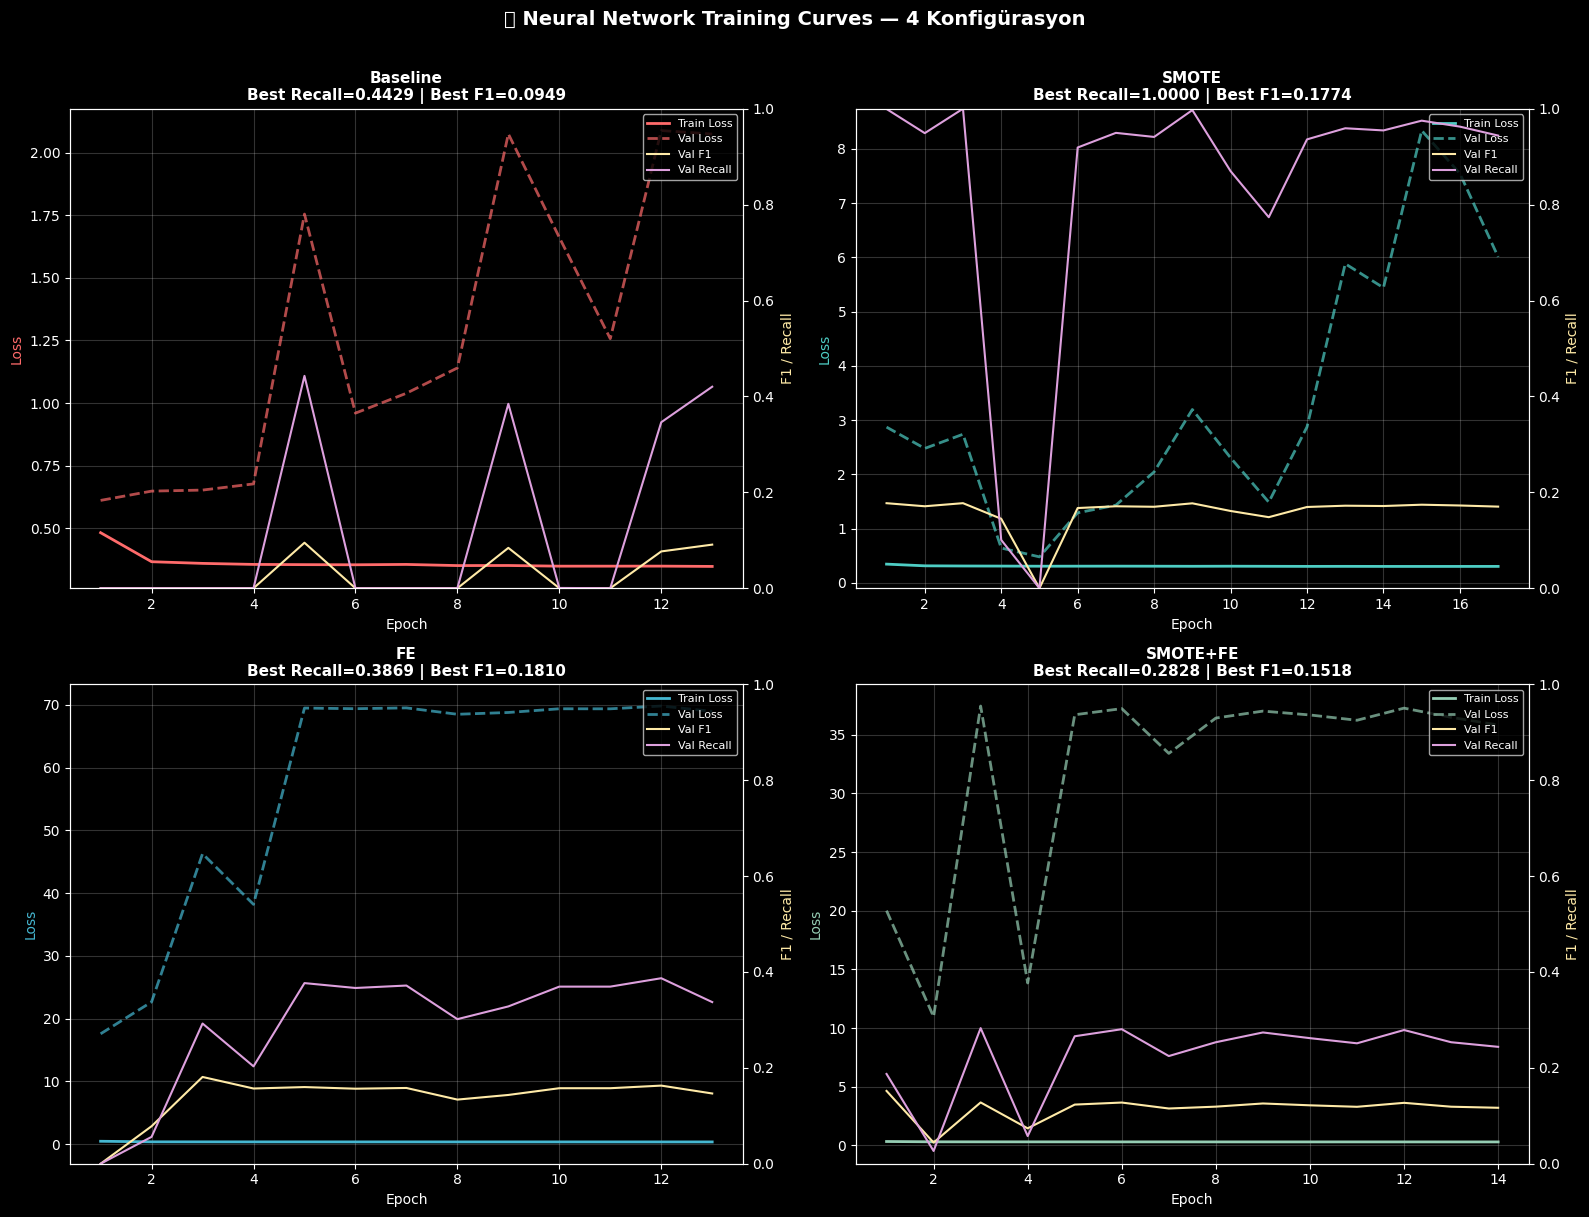

💾 nn_training_curves.png kaydedildi


In [20]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()
curve_configs = [('Baseline','#FF6B6B'),('SMOTE','#4ECDC4'),
                 ('FE','#45B7D1'),('SMOTE+FE','#96CEB4')]

for ax, (name, color) in zip(axes, curve_configs):
    h  = all_histories[name]
    ep = range(1, len(h['train_loss'])+1)
    ax2 = ax.twinx()

    ax.plot(ep, h['train_loss'], color=color, lw=2, ls='-',  label='Train Loss')
    ax.plot(ep, h['val_loss'],   color=color, lw=2, ls='--', label='Val Loss', alpha=0.7)
    ax2.plot(ep, h['val_f1'],     color='#FFEAA7', lw=1.5, label='Val F1')
    ax2.plot(ep, h['val_recall'], color='#DDA0DD', lw=1.5, label='Val Recall')

    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss', color=color)
    ax2.set_ylabel('F1 / Recall', color='#FFEAA7'); ax2.set_ylim(0, 1)
    ax.set_title(f'{name}\nBest Recall={max(h["val_recall"]):.4f} | '
                 f'Best F1={max(h["val_f1"]):.4f}',
                 fontsize=11, fontweight='bold')
    lines = ax.get_legend_handles_labels()[0] + ax2.get_legend_handles_labels()[0]
    labs  = ax.get_legend_handles_labels()[1] + ax2.get_legend_handles_labels()[1]
    ax.legend(lines, labs, fontsize=8, loc='upper right')
    ax.grid(alpha=0.2)

plt.suptitle('📈 Neural Network Training Curves — 4 Konfigürasyon',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('nn_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 nn_training_curves.png kaydedildi')


## 9. Klasik Modeller (Karşılaştırma)

In [14]:
# ── Random Forest (FE) ────────────────────────────────────────────────────────
print('⏳ Random Forest (FE özellikleriyle)...')
rf_fe = RandomForestClassifier(
    n_estimators=200, class_weight='balanced_subsample',
    min_samples_leaf=5, n_jobs=-1, random_state=RANDOM_STATE
)
# X_fe_tr_sc yerine X3_tr, X_fe_te_sc yerine X3_te kullanıldı
rf_fe.fit(X3_tr, y_train)
rf_fe_pred  = rf_fe.predict(X3_te)
rf_fe_proba = rf_fe.predict_proba(X3_te)[:, 1]

rf_fe_metrics = {
    'Config'    : 'Random Forest (FE)',
    'Accuracy'  : accuracy_score(y_test, rf_fe_pred),
    'Precision' : precision_score(y_test, rf_fe_pred, zero_division=0),
    'Recall'    : recall_score(y_test, rf_fe_pred, zero_division=0),
    'F1'        : f1_score(y_test, rf_fe_pred, zero_division=0),
    'ROC-AUC'   : roc_auc_score(y_test, rf_fe_proba),
    'PR-AUC'    : average_precision_score(y_test, rf_fe_proba),
    'y_pred'    : rf_fe_pred,
    'y_proba'   : rf_fe_proba,
}
print(f'   ✅ RF (FE) | Recall={rf_fe_metrics["Recall"]:.4f} '
      f'F1={rf_fe_metrics["F1"]:.4f}')

⏳ Random Forest (FE özellikleriyle)...
   ✅ RF (FE) | Recall=0.6657 F1=0.2349


In [15]:
# ── XGBoost (FE) ──────────────────────────────────────────────────────────────
print('\n⏳ XGBoost (FE özellikleriyle)...')
neg_fe = (y_train == 0).sum()
pos_fe = (y_train == 1).sum()

xgb_fe = xgb.XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    scale_pos_weight=neg_fe/pos_fe,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='logloss', n_jobs=-1, random_state=RANDOM_STATE
)
# Değişken isimleri X3_tr ve X3_te olarak güncellendi
xgb_fe.fit(X3_tr, y_train)
xgb_fe_pred  = xgb_fe.predict(X3_te)
xgb_fe_proba = xgb_fe.predict_proba(X3_te)[:, 1]

xgb_fe_metrics = {
    'Config'    : 'XGBoost (FE)',
    'Accuracy'  : accuracy_score(y_test, xgb_fe_pred),
    'Precision' : precision_score(y_test, xgb_fe_pred, zero_division=0),
    'Recall'    : recall_score(y_test, xgb_fe_pred, zero_division=0),
    'F1'        : f1_score(y_test, xgb_fe_pred, zero_division=0),
    'ROC-AUC'   : roc_auc_score(y_test, xgb_fe_proba),
    'PR-AUC'    : average_precision_score(y_test, xgb_fe_proba),
    'y_pred'    : xgb_fe_pred,
    'y_proba'   : xgb_fe_proba,
}
print(f'   ✅ XGBoost (FE) | Recall={xgb_fe_metrics["Recall"]:.4f} '
      f'F1={xgb_fe_metrics["F1"]:.4f}')


⏳ XGBoost (FE özellikleriyle)...
   ✅ XGBoost (FE) | Recall=0.4825 F1=0.3762


## 10. Ana Karşılaştırma Tablosu

In [17]:
# ── Karşılaştırma 1: NN vs RF vs XGBoost (hepsi FE ile) ─────────────────────
# m3 değişkenini nn_fe_metrics olarak tanımlayalım
nn_fe_metrics = m3

comp1_list = [nn_fe_metrics, rf_fe_metrics, xgb_fe_metrics]
comp1_keys = ['Accuracy','Precision','Recall','F1','ROC-AUC','PR-AUC']

comp1_df = pd.DataFrame([
    {**{'Model': m['Config']},
     **{k: f'{m[k]:.4f}' for k in comp1_keys}}
    for m in comp1_list
])

print('📊 KARŞILAŞTIRMA 1: NN vs RF vs XGBoost (Yeni Özelliklerle)')
print('='*70)
print(comp1_df.to_string(index=False))
print('='*70)

📊 KARŞILAŞTIRMA 1: NN vs RF vs XGBoost (Yeni Özelliklerle)
             Model Accuracy Precision Recall     F1 ROC-AUC PR-AUC
           NN + FE   0.9027    0.0000 0.0000 0.0000  0.5000 0.0973
Random Forest (FE)   0.5779    0.1426 0.6657 0.2349  0.6529 0.1798
      XGBoost (FE)   0.8443    0.3083 0.4825 0.3762  0.6720 0.2369


## 11. Confusion Matrix

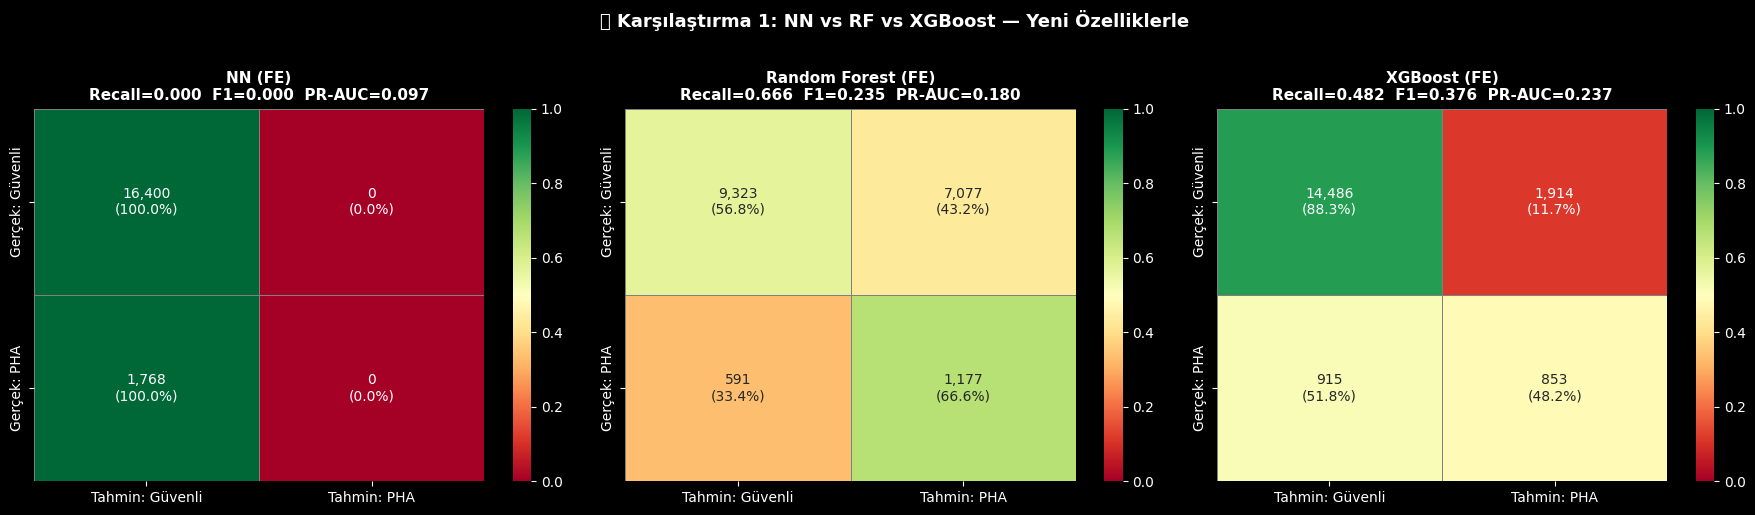

In [18]:
# ── Confusion Matrix yan yana ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
titles = ['NN (FE)', 'Random Forest (FE)', 'XGBoost (FE)']
colors_cm = ['#FF6B6B', '#4ECDC4', '#45B7D1']

for ax, m, title in zip(axes, comp1_list, titles):
    cm  = confusion_matrix(y_test, m['y_pred'])
    pct = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]
    labels = np.array([[f'{cm[r,c]:,}\n({pct[r,c]*100:.1f}%)'
                        for c in range(2)] for r in range(2)])
    sns.heatmap(pct, annot=labels, fmt='', ax=ax,
                cmap='RdYlGn', vmin=0, vmax=1,
                xticklabels=['Tahmin: Güvenli', 'Tahmin: PHA'],
                yticklabels=['Gerçek: Güvenli', 'Gerçek: PHA'],
                linewidths=0.5, linecolor='gray')
    ax.set_title(f'{title}\nRecall={m["Recall"]:.3f}  '
                 f'F1={m["F1"]:.3f}  PR-AUC={m["PR-AUC"]:.3f}',
                 fontsize=11, fontweight='bold')

plt.suptitle('🔍 Karşılaştırma 1: NN vs RF vs XGBoost — Yeni Özelliklerle',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('comp1_nn_vs_classical_FE.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. ROC & PR Eğrileri

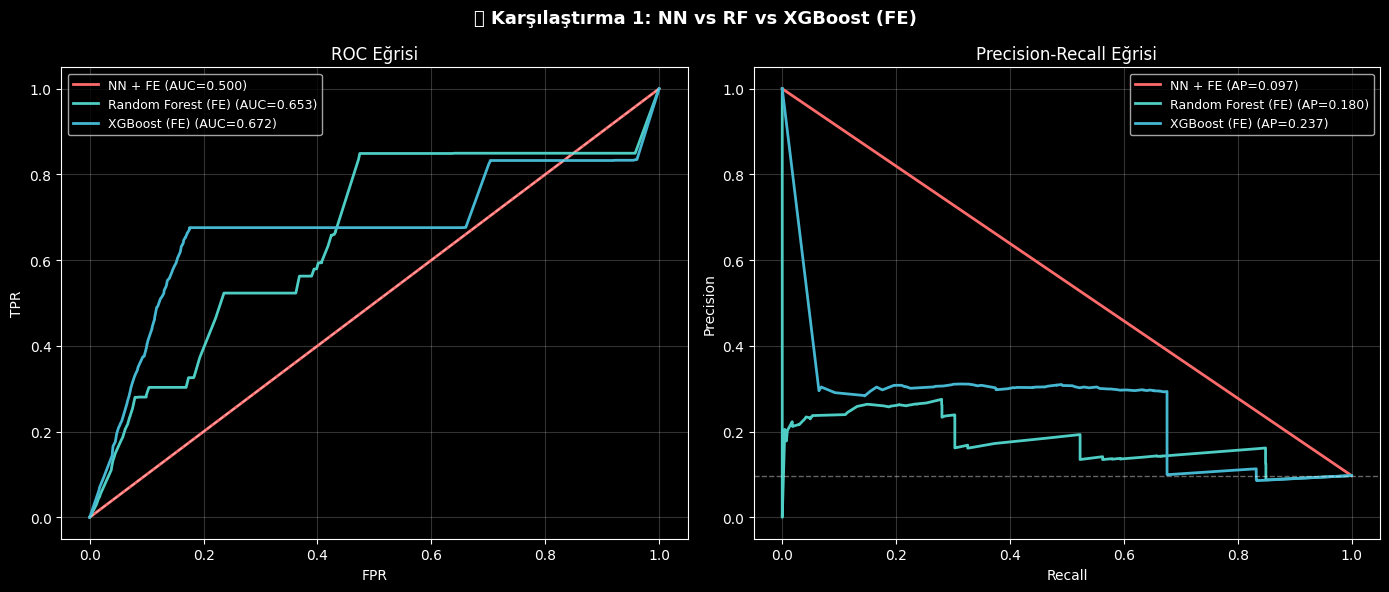

💾 comp1_nn_vs_classical_FE.png ve comp1_roc_pr_FE.png kaydedildi


In [19]:
# ── ROC Eğrisi ────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
colors3 = ['#FF6B6B', '#4ECDC4', '#45B7D1']

for m, color in zip(comp1_list, colors3):
    fpr, tpr, _ = roc_curve(y_test, m['y_proba'])
    ax1.plot(fpr, tpr, color=color, lw=2,
             label=f'{m["Config"]} (AUC={m["ROC-AUC"]:.3f})')
    prec, rec, _ = precision_recall_curve(y_test, m['y_proba'])
    ax2.plot(rec, prec, color=color, lw=2,
             label=f'{m["Config"]} (AP={m["PR-AUC"]:.3f})')

ax1.plot([0,1],[0,1],'w--',lw=1,alpha=0.4)
ax1.set_xlabel('FPR'); ax1.set_ylabel('TPR')
ax1.set_title('ROC Eğrisi'); ax1.legend(fontsize=9); ax1.grid(alpha=0.2)

ax2.axhline(y=y_test.mean(), color='w', ls='--', lw=1, alpha=0.4)
ax2.set_xlabel('Recall'); ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Eğrisi')
ax2.legend(fontsize=9); ax2.grid(alpha=0.2)

plt.suptitle('📈 Karşılaştırma 1: NN vs RF vs XGBoost (FE)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('comp1_roc_pr_FE.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 comp1_nn_vs_classical_FE.png ve comp1_roc_pr_FE.png kaydedildi')

## 13. Drive'a Kaydet

In [ ]:
import shutil, os
os.makedirs(DRIVE_PATH, exist_ok=True)

files = ['smote_comparison.png','nn_training_curves.png',
         'nn_confusion_matrices.png','nn_roc_pr_curves.png',
         'nn_radar_chart.png','nn_comparison.csv']

print('💾 Kaydediliyor...')
for f in files:
    if os.path.exists(f):
        shutil.copy(f, DRIVE_PATH + f)
        print(f'   ✅ {f}')

# En iyi NN modelini kaydet
best_model = all_metrics['SMOTE+FE']['model']
torch.save(best_model.state_dict(), 'best_nn_model.pth')
shutil.copy('best_nn_model.pth', DRIVE_PATH + 'best_nn_model.pth')
print('   ✅ best_nn_model.pth')

print(f'\n🚀 Notebook 05 tamamlandı!')

## 📋 Bu Notebook'tan Çıkarımlar

### Deney Tasarımı — Neden Bu Sıra?

```
Baseline NN          → referans nokta
    + SMOTE          → sadece veri dengesinin etkisi
    + FE             → sadece yeni özelliklerin etkisi
    + SMOTE + FE     → kombinasyonun etkisi
RF & XGBoost         → klasik modeller ile adil karşılaştırma
```

Her adımda tek değişken eklendi — bu izole ölçüm yapmanı sağlar.

### Raporun İçin Mutlaka Tartış

**Training curves hakkında:**
- Overfit var mıydı? (Train loss düşüyor ama Val loss artıyorsa evet)
- Early stopping kaçıncı epoch'ta devreye girdi?
- Batch Normalization eğitimi nasıl etkiledi?

**SMOTE hakkında:**
- Recall arttı mı? Precision ne kadar düştü?
- Trade-off kabul edilebilir mi? (Uzay güvenliğinde Recall daha önemli)

**FE hakkında:**
- Hangi yeni özellikler en çok katkı sağladı? (SHAP ile kontrol et)
- `velocity_x_distance` fiziksel olarak ne anlama geliyor?

**NN vs RF/XGBoost hakkında:**
- Tabular veride ağaç modeller NN'den iyi çalışır — bu **normal ve beklenen** bir sonuç
- Bunu raporunda tartışmak akademik olgunluğun göstergesi
- "NN her zaman en iyi değildir, problem tipine göre model seçimi kritiktir"
